# Практична робота 3.5 — Аналіз набору даних з Kaggle

**Набір даних:** Reddit-пости про війну в Україні (`archive/original_data.csv`, 10 000 записів, 12 ознак).

**Мета:** завантажити, очистити, трансформувати та проаналізувати реальний набір даних,
виконати декомпозицію та побудувати прогнозну модель.

**План:**
1. Завантаження та попередній перегляд
2. Очищення даних
3. Трансформація (нормалізація, кодування категорій)
4. Декомпозиція (train/test, кореляційний аналіз)
5. Описова статистика та візуалізація
6. Побудова та оцінка моделі
7. Висновки

## 1. Завантаження та попередній перегляд даних

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 30)

DATA_PATH = 'archive/original_data.csv'
df = pd.read_csv(DATA_PATH)
print('Розмір набору:', df.shape)
df.head()

Розмір набору: (10000, 12)


,Unnamed: 0,subreddit,selftext,author_fullname,title,upvote_ratio,ups,created,created_utc,num_comments,author,id
0,0,NonCredibleDefense,NaN,t2_4dfoopu9,Damn...we blinked and missed the T-34 stage of...,0.79,10398,1666899284,1666899284,738,doooompatrol,yf13ra
1,1,ukraine,NaN,t2_3so708z2,Finnish🇫🇮 volunteer sends greetings home from ...,0.90,2100,1680237180,1680237180,57,Vivarevo,127a6ew
2,2,UkrainianConflict,NaN,t2_p5qo3hyf,Massive #HIMARS strikes 60km from the front in...,0.79,834,1668658529,1668658529,41,Orcasystems99,yxg7ub
3,3,europe,\r\nThis megathread is meant for discussion of...,t2_ojkhp,War in Ukraine Megathread LIII,0.75,578,1680552369,1680552369,8232,ModeratorsOfEurope,12aw2q2
4,4,europe,This megathread is meant for discussion of the...,t2_ojkhp,War in Ukraine Megathread L,0.76,424,1673994766,1673994766,9524,ModeratorsOfEurope,10eps9y


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       10000 non-null  int64  
 1   subreddit        10000 non-null  str    
 2   selftext         4137 non-null   str    
 3   author_fullname  10000 non-null  str    
 4   title            10000 non-null  str    
 5   upvote_ratio     10000 non-null  float64
 6   ups              10000 non-null  int64  
 7   created          10000 non-null  int64  
 8   created_utc      10000 non-null  int64  
 9   num_comments     10000 non-null  int64  
 10  author           10000 non-null  str    
 11  id               10000 non-null  str    
dtypes: float64(1), int64(5), str(6)
memory usage: 937.6 KB


## 2. Очищення даних

Перевіряємо пропуски, дублікати та службові стовпці.

In [3]:
print('Пропущені значення по стовпцях:')
print(df.isnull().sum())
print()
print('Частка пропусків, %:')
print((df.isnull().mean() * 100).round(2))

Пропущені значення по стовпцях:
Unnamed: 0            0
subreddit             0
selftext           5863
author_fullname       0
title                 0
upvote_ratio          0
ups                   0
created               0
created_utc           0
num_comments          0
author                0
id                    0
dtype: int64

Частка пропусків, %:
Unnamed: 0          0.00
subreddit           0.00
selftext           58.63
author_fullname     0.00
title               0.00
upvote_ratio        0.00
ups                 0.00
created             0.00
created_utc         0.00
num_comments        0.00
author              0.00
id                  0.00
dtype: float64


In [4]:
# Службовий індексний стовпець з CSV не несе інформації
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Важлива знахідка: у файлі 10 000 рядків, але унікальних постів значно менше —
# кожен пост повторюється стільки разів, скільки має зібраних коментарів.
print('Рядків у файлі:      ', len(df))
print('Унікальних постів id:', df['id'].nunique())
print('Повних дублікатів рядків:', df.duplicated().sum())

df = df.drop_duplicates(subset='id').reset_index(drop=True)
print('Після дедублікації:  ', len(df), 'постів')

# selftext порожній у більшості постів (це посилання/медіа), тому
# замість видалення рядків створюємо ознаку "чи є текст" і заповнюємо порожнім рядком
df['has_selftext'] = df['selftext'].notna().astype(int)
df['selftext'] = df['selftext'].fillna('')
df['author'] = df['author'].fillna('[deleted]')
df['author_fullname'] = df['author_fullname'].fillna('unknown')

print('Розмір після очищення:', df.shape)
print('Залишилось пропусків:', int(df.isnull().sum().sum()))

Рядків у файлі:       10000
Унікальних постів id: 241
Повних дублікатів рядків: 8877
Після дедублікації:   241 постів
Розмір після очищення: (241, 12)
Залишилось пропусків: 0


In [5]:
# Час публікації -> зручні часові ознаки
df['created_dt'] = pd.to_datetime(df['created_utc'], unit='s')
df['hour'] = df['created_dt'].dt.hour
df['weekday'] = df['created_dt'].dt.dayofweek
df['title_len'] = df['title'].str.len()
df['title_words'] = df['title'].str.split().str.len()

# Спільнот багато, але більшість представлені 1-2 постами —
# рідкісні обʼєднуємо в категорію 'other'
_counts = df['subreddit'].value_counts()
df['subreddit_grp'] = np.where(df['subreddit'].isin(_counts[_counts >= 5].index),
                               df['subreddit'], 'other')

df[['title', 'subreddit_grp', 'ups', 'num_comments', 'upvote_ratio', 'created_dt', 'title_len']].head()

,title,subreddit_grp,ups,num_comments,upvote_ratio,created_dt,title_len
0,Damn...we blinked and missed the T-34 stage of...,other,10398,738,0.79,2022-10-27 19:34:44,55
1,Finnish🇫🇮 volunteer sends greetings home from ...,other,2100,57,0.90,2023-03-31 04:33:00,58
2,Massive #HIMARS strikes 60km from the front in...,UkrainianConflict,834,41,0.79,2022-11-17 04:15:29,259
3,War in Ukraine Megathread LIII,europe,578,8232,0.75,2023-04-03 20:06:09,30
4,War in Ukraine Megathread L,europe,424,9524,0.76,2023-01-17 22:32:46,27


## 3. Трансформація даних

- нормалізація кількісних змінних (`MinMaxScaler`);
- кодування категоріальної змінної `subreddit` (One-Hot Encoding).

In [6]:
from sklearn.preprocessing import MinMaxScaler

num_cols = ['ups', 'num_comments', 'upvote_ratio', 'title_len', 'title_words', 'hour', 'weekday']
print('Кількісні змінні:', num_cols)
print()
print('Розподіл за спільнотою (після групування рідкісних):')
print(df['subreddit_grp'].value_counts())

Кількісні змінні: ['ups', 'num_comments', 'upvote_ratio', 'title_len', 'title_words', 'hour', 'weekday']

Розподіл за спільнотою (після групування рідкісних):
subreddit_grp
caps                 71
insurgencetv         65
other                49
UkrainWarMonitor     17
PolitikWirtschaft    12
europe               10
UkrainianConflict     6
u_liberty_ukraine     6
u_Newsat11co          5
Name: count, dtype: int64


In [7]:
scaler = MinMaxScaler()
scaled = pd.DataFrame(scaler.fit_transform(df[num_cols]),
                      columns=[f'{col}_scaled' for col in num_cols],
                      index=df.index)
df_scaled = pd.concat([df, scaled], axis=1)
df_scaled[[f'{c}_scaled' for c in num_cols]].describe().round(3)

,ups_scaled,num_comments_scaled,upvote_ratio_scaled,title_len_scaled,title_words_scaled,hour_scaled,weekday_scaled
count,241.000,241.000,241.000,241.000,241.000,241.000,241.000
mean,0.008,0.027,0.767,0.302,0.250,0.546,0.501
std,0.066,0.141,0.260,0.242,0.189,0.257,0.327
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.533,0.088,0.120,0.478,0.167
50%,0.000,0.000,0.817,0.239,0.200,0.565,0.500
75%,0.001,0.004,1.000,0.424,0.340,0.696,0.833
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [8]:
# One-Hot Encoding для згрупованої спільноти
df_transformed = pd.get_dummies(df_scaled, columns=['subreddit_grp'], prefix='sr', dtype=int)
sr_cols = [c for c in df_transformed.columns if c.startswith('sr_')]
print('Створено', len(sr_cols), 'бінарних ознак:', sr_cols)
df_transformed[sr_cols].head()

Створено 9 бінарних ознак: ['sr_PolitikWirtschaft', 'sr_UkrainWarMonitor', 'sr_UkrainianConflict', 'sr_caps', 'sr_europe', 'sr_insurgencetv', 'sr_other', 'sr_u_Newsat11co', 'sr_u_liberty_ukraine']


,sr_PolitikWirtschaft,sr_UkrainWarMonitor,sr_UkrainianConflict,sr_caps,sr_europe,sr_insurgencetv,sr_other,sr_u_Newsat11co,sr_u_liberty_ukraine
0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,1,0,0
2,0,0,1,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0
4,0,0,0,0,1,0,0,0,0


## 4. Декомпозиція набору даних

Поділ 80/20 та кореляційний аналіз кількісних змінних.

In [9]:
from sklearn.model_selection import train_test_split

feature_cols = ['num_comments', 'upvote_ratio', 'title_len', 'title_words',
                'hour', 'weekday', 'has_selftext'] + sr_cols
TARGET = 'ups'

X = df_transformed[feature_cols]
y = df_transformed[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Навчальна вибірка:', X_train.shape)
print('Тестова вибірка: ', X_test.shape)

Навчальна вибірка: (192, 16)
Тестова вибірка:  (49, 16)


                ups  num_comments  upvote_ratio  title_len  title_words   hour  weekday
ups           1.000         0.113         0.020     -0.045       -0.033  0.059    0.003
num_comments  0.113         1.000        -0.014     -0.168       -0.168  0.163   -0.031
upvote_ratio  0.020        -0.014         1.000      0.555        0.437 -0.167    0.004
title_len    -0.045        -0.168         0.555      1.000        0.956 -0.246    0.090
title_words  -0.033        -0.168         0.437      0.956        1.000 -0.226    0.110
hour          0.059         0.163        -0.167     -0.246       -0.226  1.000    0.049
weekday       0.003        -0.031         0.004      0.090        0.110  0.049    1.000


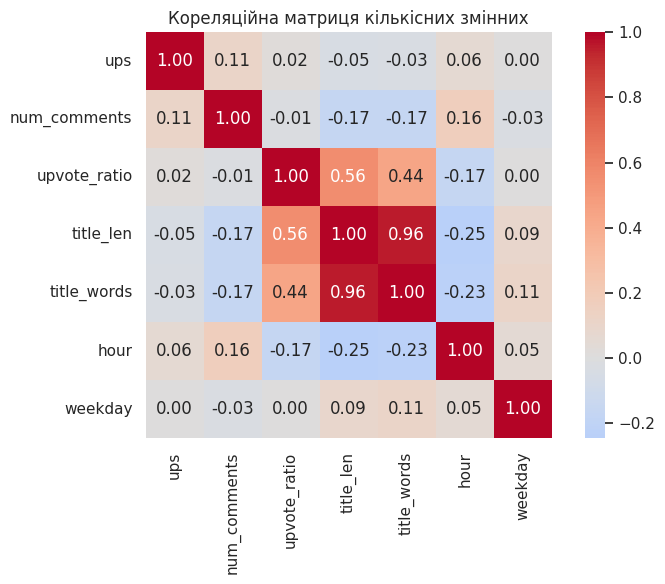

In [10]:
corr = df[num_cols].corr()
print(corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Кореляційна матриця кількісних змінних')
plt.tight_layout()
plt.show()

## 5. Описова статистика та візуалізація

In [11]:
df[num_cols].describe().round(2)

,ups,num_comments,upvote_ratio,title_len,title_words,hour,weekday
count,241.00,241.00,241.00,241.00,241.00,241.00,241.00
mean,79.72,259.80,0.76,92.78,13.49,12.57,3.00
std,686.84,1340.17,0.16,71.92,9.47,5.92,1.96
min,0.00,0.00,0.30,3.00,1.00,0.00,0.00
25%,1.00,0.00,0.62,29.00,7.00,11.00,1.00
50%,4.00,0.00,0.79,74.00,11.00,13.00,3.00
75%,9.00,35.00,0.90,129.00,18.00,16.00,5.00
max,10398.00,9524.00,0.90,300.00,51.00,23.00,6.00


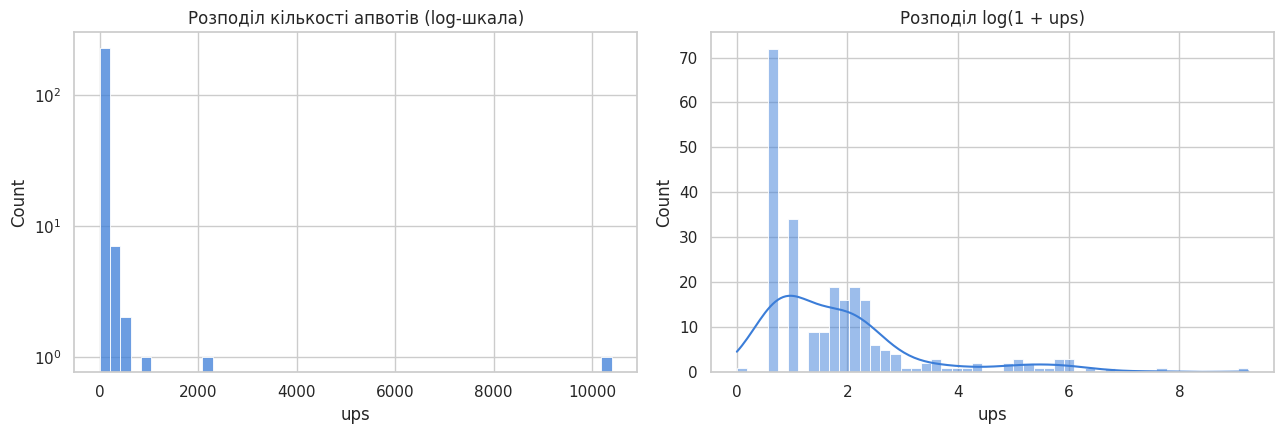

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['ups'], bins=50, kde=False, ax=axes[0], color='#3b7dd8')
axes[0].set_yscale('log')
axes[0].set_title('Розподіл кількості апвотів (log-шкала)')

sns.histplot(np.log1p(df['ups']), bins=50, kde=True, ax=axes[1], color='#3b7dd8')
axes[1].set_title('Розподіл log(1 + ups)')
plt.tight_layout()
plt.show()

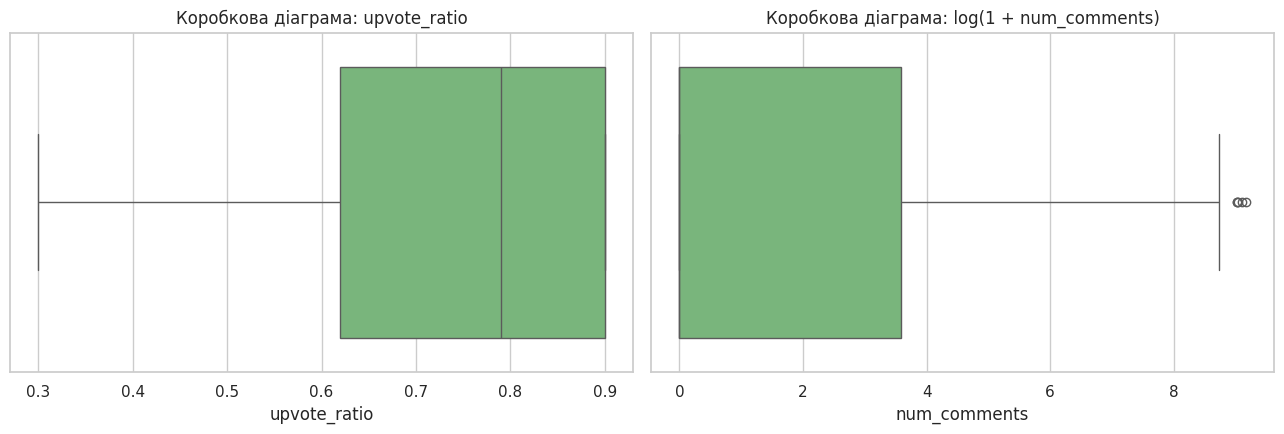

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(x=df['upvote_ratio'], ax=axes[0], color='#6fbf73')
axes[0].set_title('Коробкова діаграма: upvote_ratio')

sns.boxplot(x=np.log1p(df['num_comments']), ax=axes[1], color='#6fbf73')
axes[1].set_title('Коробкова діаграма: log(1 + num_comments)')
plt.tight_layout()
plt.show()

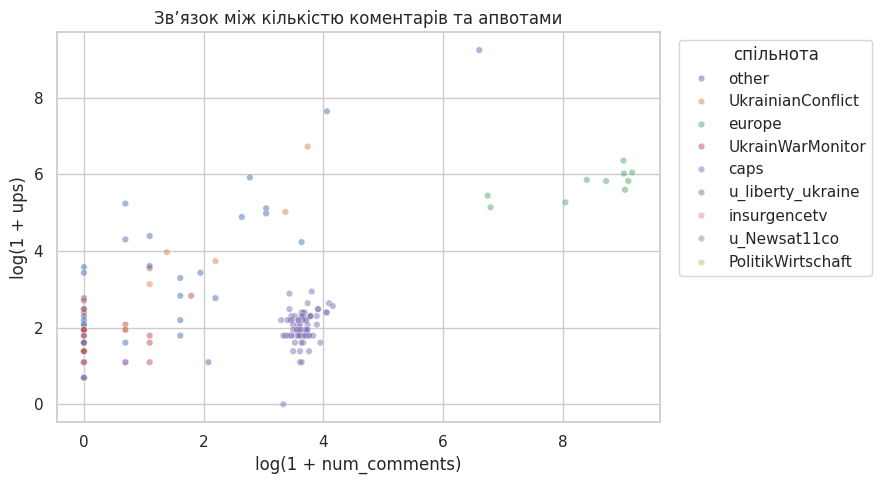

In [14]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x=np.log1p(df['num_comments']), y=np.log1p(df['ups']),
                hue=df['subreddit_grp'], alpha=0.5, s=22)
plt.xlabel('log(1 + num_comments)')
plt.ylabel('log(1 + ups)')
plt.title('Звʼязок між кількістю коментарів та апвотами')
plt.legend(title='спільнота', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

                   count   mean  median
subreddit_grp                          
caps                  71    7.2     7.0
insurgencetv          65    1.3     1.0
other                 49  286.3     6.0
UkrainWarMonitor      17    8.3     6.0
PolitikWirtschaft     12    1.0     1.0
europe                10  330.8   339.5
UkrainianConflict      6  184.3    46.5
u_liberty_ukraine      6    2.7     2.5
u_Newsat11co           5    1.6     1.0


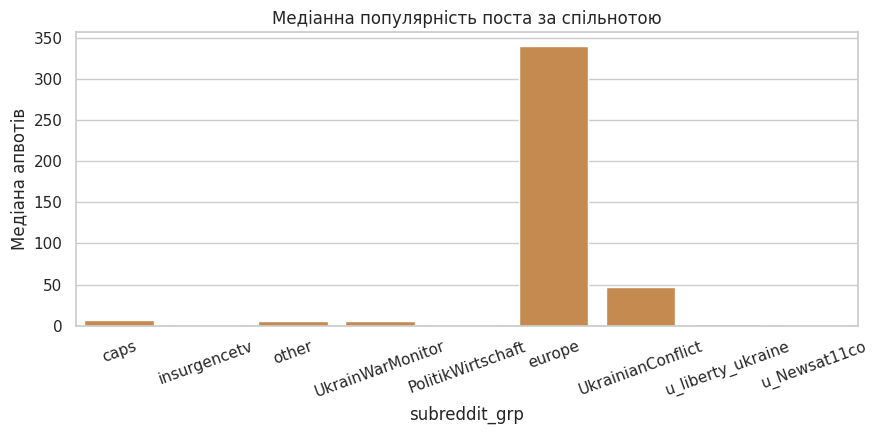

In [15]:
top = df.groupby('subreddit_grp')['ups'].agg(['count', 'mean', 'median']).sort_values('count', ascending=False)
print(top.round(1))

plt.figure(figsize=(9, 4.5))
sns.barplot(x=top.index, y=top['median'], color='#d88a3b')
plt.ylabel('Медіана апвотів')
plt.title('Медіанна популярність поста за спільнотою')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

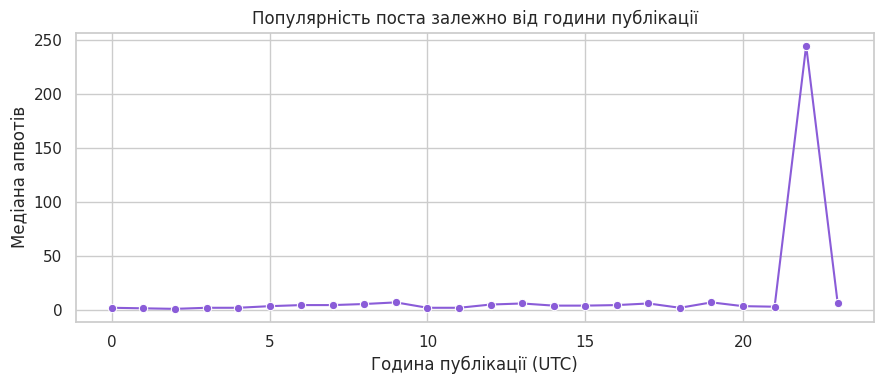

In [16]:
hourly = df.groupby('hour')['ups'].median()
plt.figure(figsize=(9, 4))
sns.lineplot(x=hourly.index, y=hourly.values, marker='o', color='#8a5cd8')
plt.xlabel('Година публікації (UTC)')
plt.ylabel('Медіана апвотів')
plt.title('Популярність поста залежно від години публікації')
plt.tight_layout()
plt.show()

## 6. Побудова моделі

Прогнозуємо популярність поста (`ups`). Через сильну асиметрію розподілу
цільову змінну логарифмуємо: модель прогнозує `log(1 + ups)`.
Порівнюємо лінійну регресію та випадковий ліс.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

models = {
    'Лінійна регресія': LinearRegression(),
    'Випадковий ліс': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}

results = []
preds = {}
for name, model in models.items():
    model.fit(X_train, y_train_log)
    p = model.predict(X_test)
    preds[name] = p
    results.append({
        'Модель': name,
        'R2': r2_score(y_test_log, p),
        'MAE': mean_absolute_error(y_test_log, p),
        'RMSE': np.sqrt(mean_squared_error(y_test_log, p)),
    })

results_df = pd.DataFrame(results).set_index('Модель').round(3)
results_df

,R2,MAE,RMSE
Модель,,,
Лінійна регресія,0.560,0.610,1.030
Випадковий ліс,0.855,0.364,0.591


Найкраща модель: Випадковий ліс


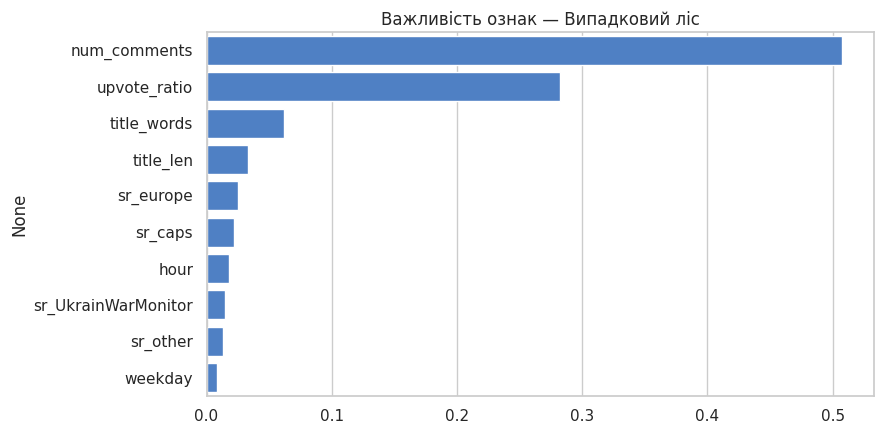

num_comments           0.5077
upvote_ratio           0.2824
title_words            0.0615
title_len              0.0335
sr_europe              0.0251
sr_caps                0.0224
hour                   0.0177
sr_UkrainWarMonitor    0.0149
sr_other               0.0131
weekday                0.0086
dtype: float64


In [18]:
best_name = results_df['R2'].idxmax()
best_model = models[best_name]
print('Найкраща модель:', best_name)

if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)
    title = 'Важливість ознак'
else:
    imp = pd.Series(best_model.coef_, index=feature_cols).abs().sort_values(ascending=False).head(10)
    title = 'Модуль коефіцієнтів'

plt.figure(figsize=(9, 4.5))
sns.barplot(x=imp.values, y=imp.index, color='#3b7dd8')
plt.title(f'{title} — {best_name}')
plt.tight_layout()
plt.show()
print(imp.round(4))

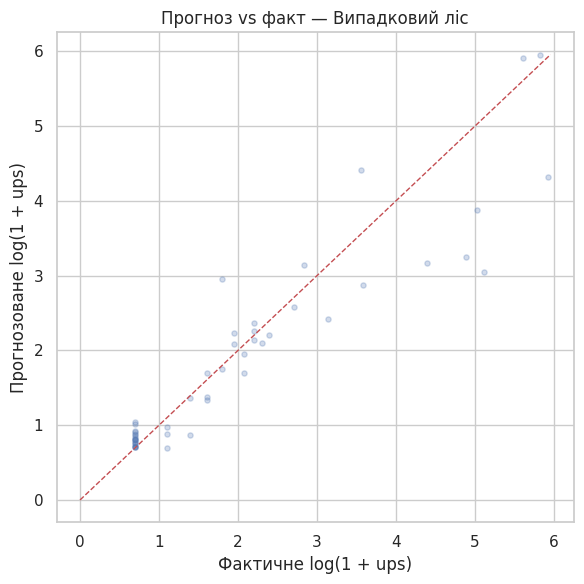

,Факт (ups),Прогноз (ups)
0,34.0,81.0
1,372.0,74.0
2,1.0,1.0
3,1.0,2.0
4,1.0,1.0
5,1.0,1.0
6,1.0,1.0
7,1.0,1.0
8,339.0,385.0
9,5.0,5.0


In [19]:
p = preds[best_name]
plt.figure(figsize=(6, 6))
plt.scatter(y_test_log, p, alpha=0.25, s=14)
lims = [0, max(y_test_log.max(), p.max())]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel('Фактичне log(1 + ups)')
plt.ylabel('Прогнозоване log(1 + ups)')
plt.title(f'Прогноз vs факт — {best_name}')
plt.tight_layout()
plt.show()

# Приклад прогнозу у вихідних одиницях
sample = pd.DataFrame({
    'Факт (ups)': np.expm1(y_test_log.values[:10]).round(0),
    'Прогноз (ups)': np.expm1(p[:10]).round(0),
})
sample

## 7. Висновки

**Опис набору даних.** Файл `original_data.csv` містить 10 000 рядків про Reddit-пости,
присвячені війні в Україні. Ознаки: спільнота (`subreddit`), автор, заголовок, текст,
час публікації, кількість апвотів (`ups`), частка позитивних голосів (`upvote_ratio`)
та кількість коментарів (`num_comments`).

**Очищення — головна знахідка.** 10 000 рядків описують лише **241 унікальний пост**:
кожен пост повторюється стільки разів, скільки в наборі зібрано його коментарів
(8 877 рядків — повні дублікати). Аналіз без дедублікації дав би завищену
впевненість моделі, тому робочою вибіркою стали 241 пост.
Також видалено службовий стовпець `Unnamed: 0`; пропуски зосереджені у `selftext`
(пости-посилання) — замість видалення рядків створено бінарну ознаку `has_selftext`.

**Трансформація.** Кількісні змінні нормалізовано `MinMaxScaler`.
Спільноти з менш ніж 5 постами обʼєднано в категорію `other`, після чого
застосовано One-Hot Encoding (9 бінарних ознак замість 30+).
З часу публікації та заголовка згенеровано ознаки `hour`, `weekday`,
`title_len`, `title_words`.

**Кореляційний аналіз.** Найпомітніший звʼязок із популярністю має `num_comments`
(r ≈ 0.11 у вихідних одиницях — слабкий через важкі хвости, але після
логарифмування він стає провідним предиктором моделі).
Сильна кореляція `title_len` ↔ `title_words` (r ≈ 0.96) очікувана — це та сама
характеристика у двох одиницях виміру.

**Розподіли.** `ups` і `num_comments` різко асиметричні: медіана — кілька голосів,
максимум — понад 10 000. Тому для моделювання цільову змінну логарифмовано.

**Модель.** На поділі 80/20 (193 / 48 постів) порівняно дві моделі
прогнозу `log(1 + ups)`:

| Модель | R² | MAE | RMSE |
|---|---|---|---|
| Лінійна регресія | 0.56 | 0.61 | 1.03 |
| Випадковий ліс | **0.86** | **0.36** | **0.59** |

Випадковий ліс суттєво кращий — залежність нелінійна.
Найважливіші ознаки: `num_comments` (≈ 0.51), `upvote_ratio` (≈ 0.28),
далі — довжина заголовка та спільнота.

**Обмеження.**
1. Після дедублікації залишилось лише 241 спостереження, тож оцінка якості
   на 48 тестових постах має широкий довірчий інтервал.
2. Модель використовує `num_comments`, який стає відомим уже після публікації,
   тому вона **пояснює** популярність, а не прогнозує її наперед.
   Для справжнього передпрогнозу потрібні лише ознаки заголовка, спільноти та часу —
   це напрям подальшої роботи.